In [2]:
from pathlib import Path
import shutil

# ===== 你只需要改这两行 =====
SRC_ROOT = Path(r"D:\PhD Research\F_Research\F_fugaku\Research\simulation\0606")   # 含有 case001, case002, ...
DST_ROOT = Path(r"D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215")
# =============================

# 你明确指定的“一级内容”
ITEMS = {
    "constant",
    "system",
    "fluent.msh",
    "a.foam",
    "submit",
}

DST_ROOT.mkdir(parents=True, exist_ok=True)

for case_dir in sorted(p for p in SRC_ROOT.iterdir() if p.is_dir()):
    dst_case = DST_ROOT / case_dir.name
    dst_case.mkdir(parents=True, exist_ok=True)

    for name in ITEMS:
        src_item = case_dir / name
        if not src_item.exists():
            continue  # 某些 case 没有也没关系

        dst_item = dst_case / name

        # 防止任何覆盖
        if dst_item.exists():
            raise RuntimeError(f"[ERROR] Already exists: {dst_item}")

        if src_item.is_dir():
            shutil.copytree(src_item, dst_item)
        else:
            shutil.copy2(src_item, dst_item)

print("Done.")


Done.


In [3]:
from pathlib import Path
import shutil

# ===== 你只需要改这两行 =====
SRC_FOLDER = Path(r"D:\PhD Research\F_Research\F_fugaku\Research\simulation\0")   # 要复制的那个文件夹
DST_ROOT   = Path(r"D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215")
# ==============================

# 基本校验（非常重要，防止路径写错）
if not SRC_FOLDER.is_dir():
    raise RuntimeError(f"Source folder not found: {SRC_FOLDER}")

if not DST_ROOT.is_dir():
    raise RuntimeError(f"Destination root not found: {DST_ROOT}")

folder_name = SRC_FOLDER.name  # 原来的名字，原样使用

for case_dir in sorted(p for p in DST_ROOT.iterdir() if p.is_dir()):
    dst = case_dir / folder_name

    # 防止任何覆盖（科研数据强烈建议）
    if dst.exists():
        raise RuntimeError(f"[ERROR] Already exists: {dst}")

    shutil.copytree(SRC_FOLDER, dst)
    print(f"Copied to: {dst}")

print("Done.")


Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0001_ICA_L_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0001_ICA_R_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0004_ICA_L_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0004_ICA_R_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0006_ICA_L_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0006_ICA_R_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0007_ICA_L_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0007_ICA_R_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0008_ICA_L_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0008_ICA_R_tube\0
Copied to: D:\PhD Research\F_Research\F_fugaku\Research\simulation\1215\BG0009_I

## Max WSS沿中心线分布

VTK version: 9.4.2
[centerline_raw] bounds x=(-7.349,15.641) y=(-37.945,29.684) z=(-15.847,26.850)
[surface_poly] bounds x=(-8.340,16.631) y=(-38.251,30.387) z=(-16.826,27.644)
Surface points: 30888 cells: 61698
Centerline raw points: 300 -> downsampled: 76 segments: 75
WSS magnitude stats: min 0.005112770206642311 max 0.16393285650527142


,seg_id,x,y,z,curvature,max_WSS,argmax_surface_pt_id
0,1,-0.554311,28.675400,-11.68600,0.034642,0.016167,1548
1,2,-0.983658,27.666599,-10.54220,0.031443,0.018017,24985
2,3,-1.413000,26.657801,-9.39849,0.026064,0.018587,24518
3,4,-1.842350,25.648899,-8.25475,0.016603,0.019183,18582
4,5,-2.271700,24.640100,-7.11101,0.012541,0.020324,18475
5,6,-2.701040,23.631300,-5.96727,0.039573,0.026420,18507
6,7,-3.130390,22.622400,-4.82353,0.086701,0.038614,8259
7,8,-3.559740,21.613600,-3.67979,0.155773,0.039750,5641
8,9,-4.015380,20.447701,-2.72551,0.238074,0.038946,5761
9,10,-4.528630,19.009100,-2.46531,0.285513,0.029516,17268


Saved: D:\github\Phd_summary\3_Result\1_Brava\2_Simulation\1_Max_WSS\output_maxWSS_per_segment.csv


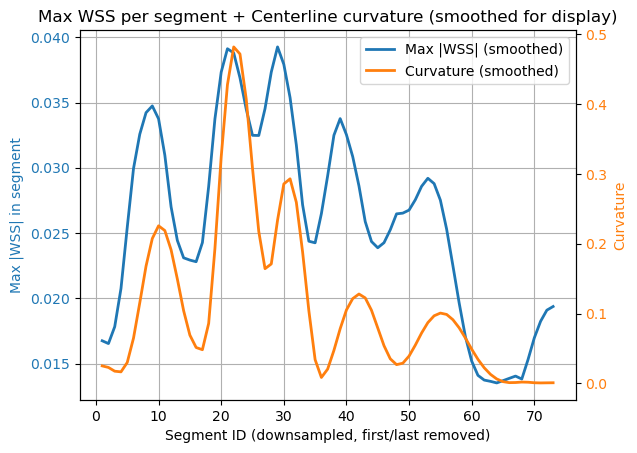

In [30]:
# %% [markdown]
# # Max scalar WSS per downsampled centerline segment (single case)
#
# - Surface: legacy .vtk, DATASET UNSTRUCTURED_GRID, with POINT_DATA wallShearStress (vector, 3 components)
# - Centerline: .vtk polyline (polydata), includes POINT_DATA curvature
# - Downsample centerline by stride (e.g., stride=4 -> ~1.2mm)
# - Segmentize centerline into independent line cells
# - For each surface point: find closest centerline segment id -> update max(|WSS|) for that segment
# - Output CSV: seg_id (unchanged), rep point coord (x,y,z), curvature, max_WSS, argmax_surface_pt_id
# - Remove first & last segments (avoid inlet/outlet boundary effects)
# - Plot: dual-y line plot (max_WSS + curvature), mildly smoothed (single curve each)

# %%
import os
import numpy as np
import pandas as pd
import vtk
import matplotlib.pyplot as plt

print("VTK version:", vtk.vtkVersion.GetVTKVersion())

# %% [markdown]
# ## 1) Paths & parameters (EDIT)

# %%
CENTERLINE_PATH = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\11_Centerline_CT_vtk\BG0020_R.vtk"
SURFACE_PATH    = r"D:\github\Phd_summary\1_Data\1_Brava\4_simulation\1_surface\BG20R_test.vtk"

stride = 4  # ~0.3mm -> ~1.2mm

OUT_CSV = r"D:\github\Phd_summary\3_Result\1_Brava\2_Simulation\1_Max_WSS\output_maxWSS_per_segment.csv"

WSS_VEC_NAME = "wallShearStress"   # PointData vector
CURV_NAME    = "curvature"         # centerline PointData scalar

# plot smoothing (Savitzky–Golay). Set None/0 to disable.
SG_WINDOW = 11   # odd >= 5 recommended
SG_POLY   = 3    # 2~3 usually good

# %% [markdown]
# ## 2) Robust readers (always return PolyData)

# %%
def print_bounds(name: str, obj):
    if obj is None:
        print(f"[{name}] None")
        return
    b = obj.GetBounds()
    print(f"[{name}] bounds x=({b[0]:.3f},{b[1]:.3f}) y=({b[2]:.3f},{b[3]:.3f}) z=({b[4]:.3f},{b[5]:.3f})")

def read_centerline_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
    elif ext == ".vtk":
        r = vtk.vtkPolyDataReader()
        # ✅ legacy vtk 多个 SCALARS 时必须全开
        r.ReadAllScalarsOn()
        r.ReadAllVectorsOn()
        r.ReadAllTensorsOn()
        r.ReadAllNormalsOn()
        r.ReadAllColorScalarsOn()
        r.ReadAllFieldsOn()
    else:
        raise ValueError(f"Unsupported centerline extension: {ext}")

    r.SetFileName(path)
    r.Update()
    out = r.GetOutput()
    if out is None or out.GetNumberOfPoints() == 0:
        raise RuntimeError(f"Failed to read/empty centerline: {path}")
    return out

def read_surface_as_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
        r.SetFileName(path)
        r.Update()
        poly = r.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Failed to read/empty VTP: {path}")
        return poly

    if ext != ".vtk":
        raise ValueError(f"Unsupported surface extension: {ext} (need .vtk or .vtp)")

    r = vtk.vtkGenericDataObjectReader()
    r.SetFileName(path)
    r.Update()
    obj = r.GetOutput()
    if obj is None:
        raise RuntimeError(f"Failed to read surface vtk: {path}")

    if obj.IsA("vtkPolyData"):
        poly = vtk.vtkPolyData.SafeDownCast(obj)
        if poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Surface polydata empty: {path}")
        return poly

    if obj.IsA("vtkDataSet"):
        ds = vtk.vtkDataSet.SafeDownCast(obj)
        surf = vtk.vtkDataSetSurfaceFilter()
        surf.SetInputData(ds)
        surf.Update()
        poly = surf.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"DataSetSurfaceFilter produced empty polydata: {path}")
        return poly

    raise RuntimeError(f"Unsupported VTK object type: {obj.GetClassName()}")

# %% [markdown]
# ## 3) Centerline utilities: FieldData fix, downsample, segmentize

# %%
def fielddata_to_pointdata_if_needed(poly: vtk.vtkPolyData):
    pts = poly.GetPoints()
    if pts is None:
        return
    n = pts.GetNumberOfPoints()
    fd = poly.GetFieldData()
    if fd is None:
        return
    for i in range(fd.GetNumberOfArrays()):
        arr = fd.GetArray(i)
        if arr is None:
            continue
        if arr.GetNumberOfTuples() == n:
            new_arr = vtk.vtkDoubleArray()
            new_arr.DeepCopy(arr)
            new_arr.SetName(arr.GetName())
            poly.GetPointData().AddArray(new_arr)
            print(f"  [fix] Centerline FieldData -> PointData: {arr.GetName()}")

def downsample_polyline_points(poly: vtk.vtkPolyData, stride: int = 4, keep_last: bool = True) -> vtk.vtkPolyData:
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Centerline has <2 points.")

    idx = list(range(0, n, stride))
    if keep_last and idx[-1] != n - 1:
        idx.append(n - 1)

    new_points = vtk.vtkPoints()
    new_points.SetNumberOfPoints(len(idx))
    for j, i in enumerate(idx):
        new_points.SetPoint(j, pts.GetPoint(i))

    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(idx))
    for j in range(len(idx)):
        polyline.GetPointIds().SetId(j, j)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(polyline)

    new_pd = vtk.vtkPolyData()
    new_pd.SetPoints(new_points)
    new_pd.SetLines(lines)

    # copy point arrays by sampling the selected indices
    src_pd = poly.GetPointData()
    dst_pd = new_pd.GetPointData()
    for a in range(src_pd.GetNumberOfArrays()):
        arr = src_pd.GetArray(a)
        if arr is None:
            continue
        name = arr.GetName()
        ncomp = arr.GetNumberOfComponents()
        new_arr = vtk.vtkDoubleArray()
        new_arr.SetName(name)
        new_arr.SetNumberOfComponents(ncomp)
        new_arr.SetNumberOfTuples(len(idx))
        for j, i in enumerate(idx):
            new_arr.SetTuple(j, arr.GetTuple(i))
        dst_pd.AddArray(new_arr)

    return new_pd

def segmentize_centerline(poly: vtk.vtkPolyData) -> vtk.vtkPolyData:
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Need at least 2 points to segmentize.")

    new_lines = vtk.vtkCellArray()
    for i in range(n - 1):
        line = vtk.vtkLine()
        line.GetPointIds().SetId(0, i)
        line.GetPointIds().SetId(1, i + 1)
        new_lines.InsertNextCell(line)

    out = vtk.vtkPolyData()
    out.SetPoints(pts)
    out.SetLines(new_lines)
    out.GetPointData().ShallowCopy(poly.GetPointData())
    return out

# --- plotting smoother (no extra dependency) ---
def savgol_smooth(y: np.ndarray, window: int, poly: int) -> np.ndarray:
    """
    Lightweight Savitzky–Golay smoothing without scipy.
    Uses local polynomial least squares (centered) with reflect padding.
    """
    y = np.asarray(y, dtype=float)
    n = y.size
    if not window:
        return y
    window = int(window)
    poly = int(poly)
    if window < 5 or window % 2 == 0 or window > n:
        return y
    if poly >= window:
        poly = window - 1

    half = window // 2
    ypad = np.r_[y[half:0:-1], y, y[-2:-half-2:-1]]

    x = np.arange(-half, half + 1, dtype=float)
    A = np.vander(x, poly + 1, increasing=True)
    pinv = np.linalg.pinv(A)
    coeff = pinv[0]  # center value weights

    out = np.empty(n, dtype=float)
    for i in range(n):
        out[i] = np.dot(coeff, ypad[i:i + window])
    return out

def interp_nan(y: np.ndarray) -> np.ndarray:
    y = y.astype(float).copy()
    n = y.size
    good = np.isfinite(y)
    if good.sum() < 2:
        return y
    xi = np.arange(n)
    y[~good] = np.interp(xi[~good], xi[good], y[good])
    return y

# %% [markdown]
# ## 4) Load data

# %%
raw_cl = read_centerline_polydata(CENTERLINE_PATH)
fielddata_to_pointdata_if_needed(raw_cl)

surface = read_surface_as_polydata(SURFACE_PATH)

print_bounds("centerline_raw", raw_cl)
print_bounds("surface_poly", surface)
print("Surface points:", surface.GetNumberOfPoints(), "cells:", surface.GetNumberOfCells())

# downsample + segmentize
cl_ds = downsample_polyline_points(raw_cl, stride=stride, keep_last=True)
cl_seg = segmentize_centerline(cl_ds)

n_pts = cl_ds.GetNumberOfPoints()
n_segs = cl_seg.GetNumberOfCells()
print("Centerline raw points:", raw_cl.GetNumberOfPoints(), "-> downsampled:", n_pts, "segments:", n_segs)

# representative coordinate for each segment: point k (same index as seg_id)
cl_points = np.array([cl_ds.GetPoint(i) for i in range(n_pts)], dtype=float)

# curvature array
pd_cl = cl_ds.GetPointData()
if not pd_cl.HasArray(CURV_NAME):
    avail = [pd_cl.GetArrayName(i) for i in range(pd_cl.GetNumberOfArrays())]
    raise RuntimeError(f"Centerline has no '{CURV_NAME}'. Available arrays: {avail}")

curv_arr = pd_cl.GetArray(CURV_NAME)
if curv_arr.GetNumberOfComponents() != 1:
    raise RuntimeError(f"'{CURV_NAME}' components={curv_arr.GetNumberOfComponents()} (expected 1).")

curv_pt = np.array([curv_arr.GetTuple1(i) for i in range(n_pts)], dtype=float)
curv_seg = curv_pt[:-1].copy()  # segment k uses point k curvature

# locator for segments
locator = vtk.vtkCellLocator()
locator.SetDataSet(cl_seg)
locator.BuildLocator()

# %% [markdown]
# ## 5) WSS magnitude from surface

# %%
pd_surf = surface.GetPointData()
if not pd_surf.HasArray(WSS_VEC_NAME):
    names = [pd_surf.GetArrayName(i) for i in range(pd_surf.GetNumberOfArrays())]
    raise RuntimeError(f"Surface PointData has no '{WSS_VEC_NAME}'. Available arrays: {names}")

arr = pd_surf.GetArray(WSS_VEC_NAME)
if arr.GetNumberOfComponents() != 3:
    raise RuntimeError(f"'{WSS_VEC_NAME}' components={arr.GetNumberOfComponents()} (expected 3).")

wss_vec = np.array([arr.GetTuple3(i) for i in range(surface.GetNumberOfPoints())], dtype=float)
wss_mag = np.linalg.norm(wss_vec, axis=1)
print("WSS magnitude stats: min", float(wss_mag.min()), "max", float(wss_mag.max()))

# %% [markdown]
# ## 6) Per-segment max WSS

# %%
max_wss = np.full(n_segs, -np.inf, dtype=float)
argmax_pt = np.full(n_segs, -1, dtype=int)

closest_pos = [0.0, 0.0, 0.0]
cell_id = vtk.reference(0)
sub_id  = vtk.reference(0)
dist2   = vtk.reference(0.0)

for i in range(surface.GetNumberOfPoints()):
    p = surface.GetPoint(i)
    locator.FindClosestPoint(p, closest_pos, cell_id, sub_id, dist2)
    k = int(cell_id)  # seg id

    w = wss_mag[i]
    if w > max_wss[k]:
        max_wss[k] = w
        argmax_pt[k] = i

max_wss[np.isneginf(max_wss)] = np.nan

# %% [markdown]
# ## 7) Build result table + save CSV (exclude first/last segments)

# %%
rows = []
for k in range(1, n_segs - 1):  # ✅ remove first & last (keep seg_id unchanged)
    x, y, z = cl_points[k]  # representative coordinate for seg_id=k
    rows.append({
        "seg_id": int(k),
        "x": float(x), "y": float(y), "z": float(z),
        "curvature": float(curv_seg[k]),
        "max_WSS": float(max_wss[k]) if np.isfinite(max_wss[k]) else np.nan,
        "argmax_surface_pt_id": int(argmax_pt[k]),
    })

df = pd.DataFrame(rows)
display(df.head(10))

if OUT_CSV and OUT_CSV.strip():
    df.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

# %% [markdown]
# ## 8) Plot: dual y-axis (max_WSS + curvature), smoothed for display, two colors

# %%
x = df["seg_id"].to_numpy(dtype=int)

y_wss = df["max_WSS"].to_numpy(dtype=float)
y_cur = df["curvature"].to_numpy(dtype=float)

# plot-only nan handling + smoothing
y_wss_plot = savgol_smooth(interp_nan(y_wss), SG_WINDOW, SG_POLY)
y_cur_plot = savgol_smooth(interp_nan(y_cur), SG_WINDOW, SG_POLY)

fig, ax1 = plt.subplots()

# WSS line (color specified by your request)
ax1.plot(x, y_wss_plot, linewidth=2, color="tab:blue", label="Max |WSS| (smoothed)")
ax1.set_xlabel("Segment ID (downsampled, first/last removed)")
ax1.set_ylabel("Max |WSS| in segment", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

# Curvature line on right axis
ax2 = ax1.twinx()
ax2.plot(x, y_cur_plot, linewidth=2, color="tab:orange", label="Curvature (smoothed)")
ax2.set_ylabel("Curvature", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Max WSS per segment + Centerline curvature (smoothed for display)")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.show()


VTK version: 9.4.2
[centerline_raw] bounds x=(-7.349,15.641) y=(-37.945,29.684) z=(-15.847,26.850)
[surface_poly] bounds x=(-8.340,16.631) y=(-38.251,30.387) z=(-16.826,27.644)
Surface points: 30888 cells: 61698
Centerline raw points: 300 -> downsampled: 76 segments: 75
WSS magnitude stats: min 0.005112770206642311 max 0.16393285650527142


,seg_id,s,x,y,z,curvature,max_WSS,argmax_surface_pt_id
0,1,1.584320,-0.554311,28.675400,-11.68600,0.034642,0.016167,1548
1,2,3.168711,-0.983658,27.666599,-10.54220,0.031443,0.018017,24985
2,3,4.753034,-1.413000,26.657801,-9.39849,0.026064,0.018587,24518
3,4,6.337447,-1.842350,25.648899,-8.25475,0.016603,0.019183,18582
4,5,7.921795,-2.271700,24.640100,-7.11101,0.012541,0.020324,18475
5,6,9.506141,-2.701040,23.631300,-5.96727,0.039573,0.026420,18507
6,7,11.090553,-3.130390,22.622400,-4.82353,0.086701,0.038614,8259
7,8,12.674902,-3.559740,21.613600,-3.67979,0.155773,0.039750,5641
8,9,14.248935,-4.015380,20.447701,-2.72551,0.238074,0.038946,5761
9,10,15.798354,-4.528630,19.009100,-2.46531,0.285513,0.029516,17268


Saved: D:\github\Phd_summary\3_Result\1_Brava\2_Simulation\1_Max_WSS\output_maxWSS_per_segment.csv


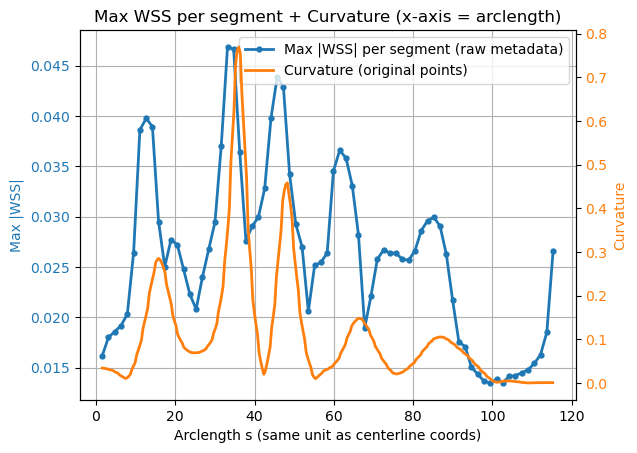

In [34]:
# %% [markdown]
# # Max scalar WSS per downsampled centerline segment (single case)
#
# - Surface: legacy .vtk, DATASET UNSTRUCTURED_GRID, with POINT_DATA wallShearStress (vector, 3 components)
# - Centerline: .vtk polyline (polydata), includes POINT_DATA curvature
# - Downsample centerline by stride (e.g., stride=4 -> ~1.2mm)
# - Segmentize downsampled centerline into independent line cells
# - For each surface point: closest segment id -> update max(|WSS|) for that segment
# - CSV: seg_id (unchanged), rep point coord (x,y,z), rep arclength s, curvature(at rep point), max_WSS, argmax_surface_pt_id
# - Plot x-axis = arclength:
#     * curvature plotted using ORIGINAL centerline points (dense)
#     * max_WSS plotted using DOWNSAMPLED segments (sparse)
# - Exclude first & last segments (avoid inlet/outlet boundary effects)

# %%
import os
import numpy as np
import pandas as pd
import vtk
import matplotlib.pyplot as plt

print("VTK version:", vtk.vtkVersion.GetVTKVersion())

# %% [markdown]
# ## 1) Paths & parameters (EDIT)

# %%
CENTERLINE_PATH = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\11_Centerline_CT_vtk\BG0020_R.vtk"
SURFACE_PATH    = r"D:\github\Phd_summary\1_Data\1_Brava\4_simulation\1_surface\BG20R_test.vtk"

stride = 4  # ~0.3mm -> ~1.2mm

OUT_CSV = r"D:\github\Phd_summary\3_Result\1_Brava\2_Simulation\1_Max_WSS\output_maxWSS_per_segment.csv"

WSS_VEC_NAME = "wallShearStress"   # surface PointData vector (3 comps)
CURV_NAME    = "curvature"         # centerline PointData scalar

# plot smoothing for nicer look (plot-only; CSV untouched)
# Set to 0 to disable smoothing.
WSS_SG_WINDOW  = 11   # odd
WSS_SG_POLY    = 3
CURV_SG_WINDOW = 31   # curvature is denser -> can use larger window
CURV_SG_POLY   = 3

# %% [markdown]
# ## 2) Robust readers (always return PolyData)

# %%
def print_bounds(name: str, obj):
    if obj is None:
        print(f"[{name}] None")
        return
    b = obj.GetBounds()
    print(f"[{name}] bounds x=({b[0]:.3f},{b[1]:.3f}) y=({b[2]:.3f},{b[3]:.3f}) z=({b[4]:.3f},{b[5]:.3f})")

def read_centerline_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
    elif ext == ".vtk":
        r = vtk.vtkPolyDataReader()
        # ✅ legacy vtk 多个 SCALARS 时必须全开
        r.ReadAllScalarsOn()
        r.ReadAllVectorsOn()
        r.ReadAllTensorsOn()
        r.ReadAllNormalsOn()
        r.ReadAllColorScalarsOn()
        r.ReadAllFieldsOn()
    else:
        raise ValueError(f"Unsupported centerline extension: {ext}")

    r.SetFileName(path)
    r.Update()
    out = r.GetOutput()
    if out is None or out.GetNumberOfPoints() == 0:
        raise RuntimeError(f"Failed to read/empty centerline: {path}")
    return out

def read_surface_as_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
        r.SetFileName(path)
        r.Update()
        poly = r.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Failed to read/empty VTP: {path}")
        return poly

    if ext != ".vtk":
        raise ValueError(f"Unsupported surface extension: {ext} (need .vtk or .vtp)")

    r = vtk.vtkGenericDataObjectReader()
    r.SetFileName(path)
    r.Update()
    obj = r.GetOutput()
    if obj is None:
        raise RuntimeError(f"Failed to read surface vtk: {path}")

    if obj.IsA("vtkPolyData"):
        poly = vtk.vtkPolyData.SafeDownCast(obj)
        if poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Surface polydata empty: {path}")
        return poly

    if obj.IsA("vtkDataSet"):
        ds = vtk.vtkDataSet.SafeDownCast(obj)
        surf = vtk.vtkDataSetSurfaceFilter()
        surf.SetInputData(ds)
        surf.Update()
        poly = surf.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"DataSetSurfaceFilter produced empty polydata: {path}")
        return poly

    raise RuntimeError(f"Unsupported VTK object type: {obj.GetClassName()}")

# %% [markdown]
# ## 3) Utilities: downsample, segmentize, arclength, plot smoothing (no scipy)

# %%
def downsample_polyline_points(poly: vtk.vtkPolyData, stride: int = 4, keep_last: bool = True):
    """Return (new_polydata, kept_indices_in_original)."""
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Centerline has <2 points.")

    idx = list(range(0, n, stride))
    if keep_last and idx[-1] != n - 1:
        idx.append(n - 1)

    new_points = vtk.vtkPoints()
    new_points.SetNumberOfPoints(len(idx))
    for j, i in enumerate(idx):
        new_points.SetPoint(j, pts.GetPoint(i))

    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(idx))
    for j in range(len(idx)):
        polyline.GetPointIds().SetId(j, j)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(polyline)

    new_pd = vtk.vtkPolyData()
    new_pd.SetPoints(new_points)
    new_pd.SetLines(lines)

    # copy point arrays by sampling the selected indices
    src_pd = poly.GetPointData()
    dst_pd = new_pd.GetPointData()
    for a in range(src_pd.GetNumberOfArrays()):
        arr = src_pd.GetArray(a)
        if arr is None:
            continue
        name = arr.GetName()
        ncomp = arr.GetNumberOfComponents()
        new_arr = vtk.vtkDoubleArray()
        new_arr.SetName(name)
        new_arr.SetNumberOfComponents(ncomp)
        new_arr.SetNumberOfTuples(len(idx))
        for j, i in enumerate(idx):
            new_arr.SetTuple(j, arr.GetTuple(i))
        dst_pd.AddArray(new_arr)

    return new_pd, idx

def segmentize_centerline(poly: vtk.vtkPolyData) -> vtk.vtkPolyData:
    """Convert polyline points into N-1 independent vtkLine cells."""
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Need at least 2 points to segmentize.")

    new_lines = vtk.vtkCellArray()
    for i in range(n - 1):
        line = vtk.vtkLine()
        line.GetPointIds().SetId(0, i)
        line.GetPointIds().SetId(1, i + 1)
        new_lines.InsertNextCell(line)

    out = vtk.vtkPolyData()
    out.SetPoints(pts)
    out.SetLines(new_lines)
    out.GetPointData().ShallowCopy(poly.GetPointData())
    return out

def cumulative_arclength(points_np: np.ndarray) -> np.ndarray:
    dif = np.diff(points_np, axis=0)
    seg = np.linalg.norm(dif, axis=1)
    s = np.zeros(points_np.shape[0], dtype=float)
    s[1:] = np.cumsum(seg)
    return s

def interp_nan(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float).copy()
    n = y.size
    good = np.isfinite(y)
    if good.sum() < 2:
        return y
    xi = np.arange(n)
    y[~good] = np.interp(xi[~good], xi[good], y[good])
    return y

def savgol_smooth(y: np.ndarray, window: int, poly: int) -> np.ndarray:
    """
    Lightweight Savitzky–Golay smoothing without scipy.
    Reflect padding + local poly LS; returns same length.
    """
    y = np.asarray(y, dtype=float)
    n = y.size
    window = int(window) if window else 0
    poly = int(poly) if poly else 0
    if window <= 0:
        return y
    if window < 5 or window % 2 == 0 or window > n:
        return y
    if poly >= window:
        poly = window - 1

    half = window // 2
    ypad = np.r_[y[half:0:-1], y, y[-2:-half-2:-1]]

    x = np.arange(-half, half + 1, dtype=float)
    A = np.vander(x, poly + 1, increasing=True)
    pinv = np.linalg.pinv(A)
    w = pinv[0]  # center value weights

    out = np.empty(n, dtype=float)
    for i in range(n):
        out[i] = np.dot(w, ypad[i:i + window])
    return out

# %% [markdown]
# ## 4) Load data

# %%
raw_cl = read_centerline_polydata(CENTERLINE_PATH)
surface = read_surface_as_polydata(SURFACE_PATH)

print_bounds("centerline_raw", raw_cl)
print_bounds("surface_poly", surface)
print("Surface points:", surface.GetNumberOfPoints(), "cells:", surface.GetNumberOfCells())

# raw arrays
raw_pts = np.array([raw_cl.GetPoint(i) for i in range(raw_cl.GetNumberOfPoints())], dtype=float)
s_raw = cumulative_arclength(raw_pts)

pd_raw = raw_cl.GetPointData()
if not pd_raw.HasArray(CURV_NAME):
    avail = [pd_raw.GetArrayName(i) for i in range(pd_raw.GetNumberOfArrays())]
    raise RuntimeError(f"Centerline raw has no '{CURV_NAME}'. Available arrays: {avail}")

curv_raw_arr = pd_raw.GetArray(CURV_NAME)
if curv_raw_arr.GetNumberOfComponents() != 1:
    raise RuntimeError(f"'{CURV_NAME}' components={curv_raw_arr.GetNumberOfComponents()} (expected 1).")
curv_raw = np.array([curv_raw_arr.GetTuple1(i) for i in range(raw_cl.GetNumberOfPoints())], dtype=float)

# downsample centerline
cl_ds, kept_idx = downsample_polyline_points(raw_cl, stride=stride, keep_last=True)
cl_seg = segmentize_centerline(cl_ds)

ds_pts = np.array([cl_ds.GetPoint(i) for i in range(cl_ds.GetNumberOfPoints())], dtype=float)
s_ds = cumulative_arclength(ds_pts)

n_pts = cl_ds.GetNumberOfPoints()
n_segs = cl_seg.GetNumberOfCells()
print("Centerline raw points:", raw_cl.GetNumberOfPoints(), "-> downsampled:", n_pts, "segments:", n_segs)

# downsampled curvature (for CSV)
pd_ds = cl_ds.GetPointData()
if not pd_ds.HasArray(CURV_NAME):
    # theoretically shouldn't happen because we sampled arrays; but keep safe
    avail = [pd_ds.GetArrayName(i) for i in range(pd_ds.GetNumberOfArrays())]
    raise RuntimeError(f"Centerline downsampled has no '{CURV_NAME}'. Available arrays: {avail}")

curv_ds_arr = pd_ds.GetArray(CURV_NAME)
curv_ds_pt = np.array([curv_ds_arr.GetTuple1(i) for i in range(n_pts)], dtype=float)
curv_ds_seg = curv_ds_pt[:-1].copy()  # segment k uses point k curvature

# locator
locator = vtk.vtkCellLocator()
locator.SetDataSet(cl_seg)
locator.BuildLocator()

# %% [markdown]
# ## 5) WSS magnitude from surface

# %%
pd_surf = surface.GetPointData()
if not pd_surf.HasArray(WSS_VEC_NAME):
    names = [pd_surf.GetArrayName(i) for i in range(pd_surf.GetNumberOfArrays())]
    raise RuntimeError(f"Surface PointData has no '{WSS_VEC_NAME}'. Available arrays: {names}")

wss_arr = pd_surf.GetArray(WSS_VEC_NAME)
if wss_arr.GetNumberOfComponents() != 3:
    raise RuntimeError(f"'{WSS_VEC_NAME}' components={wss_arr.GetNumberOfComponents()} (expected 3).")

wss_vec = np.array([wss_arr.GetTuple3(i) for i in range(surface.GetNumberOfPoints())], dtype=float)
wss_mag = np.linalg.norm(wss_vec, axis=1)
print("WSS magnitude stats: min", float(wss_mag.min()), "max", float(wss_mag.max()))

# %% [markdown]
# ## 6) Per-segment max WSS

# %%
max_wss = np.full(n_segs, -np.inf, dtype=float)
argmax_pt = np.full(n_segs, -1, dtype=int)

closest_pos = [0.0, 0.0, 0.0]
cell_id = vtk.reference(0)
sub_id  = vtk.reference(0)
dist2   = vtk.reference(0.0)

for i in range(surface.GetNumberOfPoints()):
    p = surface.GetPoint(i)
    locator.FindClosestPoint(p, closest_pos, cell_id, sub_id, dist2)
    k = int(cell_id)

    w = wss_mag[i]
    if w > max_wss[k]:
        max_wss[k] = w
        argmax_pt[k] = i

max_wss[np.isneginf(max_wss)] = np.nan

# %% [markdown]
# ## 7) CSV: keep seg_id unchanged; record (s, x,y,z, curvature, max_WSS)

# %%
rows = []
for k in range(1, n_segs - 1):  # ✅ remove first & last segments, seg_id not renumbered
    x, y, z = ds_pts[k]         # representative coordinate for seg k = point k (downsampled)
    rows.append({
        "seg_id": int(k),
        "s": float(s_ds[k]),          # ✅ x-axis length coordinate
        "x": float(x), "y": float(y), "z": float(z),
        "curvature": float(curv_ds_seg[k]),
        "max_WSS": float(max_wss[k]) if np.isfinite(max_wss[k]) else np.nan,
        "argmax_surface_pt_id": int(argmax_pt[k]),
    })

df = pd.DataFrame(rows)
display(df.head(10))

if OUT_CSV and OUT_CSV.strip():
    df.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

# %% [markdown]
# ## 8) Plot: x = arclength
# - Max WSS: downsampled segments (NO smoothing) as polyline
# - Curvature: ORIGINAL centerline points (can be smoothed for nicer look; optional)

# %%
# --- WSS: NO smoothing, use polyline ---
x_wss = df["s"].to_numpy(dtype=float)
y_wss = df["max_WSS"].to_numpy(dtype=float)

# --- Curvature: ORIGINAL points ---
s_min = float(np.nanmin(x_wss))
s_max = float(np.nanmax(x_wss))
mask_cur = (s_raw >= s_min) & (s_raw <= s_max)

x_cur = s_raw[mask_cur]
y_cur = curv_raw[mask_cur]

# （可选）仅让 curvature 视觉更顺一点；不想平滑就把下一行改成 y_cur_plot = y_cur
y_cur_plot = y_cur


# --- plot ---
fig, ax1 = plt.subplots()

# ✅ MaxWSS：折线图（元数据），不做 smooth
ax1.plot(x_wss, y_wss, linestyle="-", linewidth=2.0, marker="o", markersize=3.5,
         color="tab:blue", label="Max |WSS| per segment (raw metadata)")
ax1.set_xlabel("Arclength s (same unit as centerline coords)")
ax1.set_ylabel("Max |WSS|", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

# Curvature on second axis
ax2 = ax1.twinx()
ax2.plot(x_cur, y_cur_plot, linewidth=2.0, color="tab:orange",
         label="Curvature (original points)")
ax2.set_ylabel("Curvature", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Max WSS per segment + Curvature (x-axis = arclength)")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.show()



In [35]:
import os
import numpy as np
import vtk

# =========================
# EDIT: paths & params
# =========================
CENTERLINE_PATH = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\11_Centerline_CT_vtk\BG0020_R.vtk"
SURFACE_PATH    = r"D:\github\Phd_summary\1_Data\1_Brava\4_simulation\1_surface\BG20R_test.vtk"

OUT_SURFACE_VTK = r"D:\github\Phd_summary\1_Data\1_Brava\4_simulation\1_surface\BG20R_surface_labeled_by_1p2mm.vtk"

stride = 4  # ~0.3mm -> ~1.2mm

# 如果发现 surface 与 centerline 单位不一致（例如 surface=mm, centerline=m），在这里调整
# 常见情况：两个都是 mm -> 都用 1.0
# 如果你要把 mm->m：scale = 1e-3
SCALE_CENTERLINE = 1.0
SCALE_SURFACE    = 1.0

# 是否把第一个/最后一个 segment 标为 -1（避免入口出口区域）
EXCLUDE_FIRST_LAST_SEG = True

# 输出数组名（ParaView 里用它来 Color by）
SEG_ID_NAME = "SegID_1p2mm"

# =========================
# Readers
# =========================
def read_centerline_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
    elif ext == ".vtk":
        r = vtk.vtkPolyDataReader()
        r.ReadAllScalarsOn()
        r.ReadAllVectorsOn()
        r.ReadAllTensorsOn()
        r.ReadAllNormalsOn()
        r.ReadAllColorScalarsOn()
        r.ReadAllFieldsOn()
    else:
        raise ValueError(f"Unsupported centerline extension: {ext}")

    r.SetFileName(path)
    r.Update()
    out = r.GetOutput()
    if out is None or out.GetNumberOfPoints() == 0:
        raise RuntimeError(f"Failed to read/empty centerline: {path}")
    return out

def read_surface_as_polydata(path: str) -> vtk.vtkPolyData:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".vtp":
        r = vtk.vtkXMLPolyDataReader()
        r.SetFileName(path)
        r.Update()
        poly = r.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Failed to read/empty VTP: {path}")
        return poly

    if ext != ".vtk":
        raise ValueError(f"Unsupported surface extension: {ext} (need .vtk or .vtp)")

    r = vtk.vtkGenericDataObjectReader()
    r.SetFileName(path)
    r.Update()
    obj = r.GetOutput()
    if obj is None:
        raise RuntimeError(f"Failed to read surface vtk: {path}")

    if obj.IsA("vtkPolyData"):
        poly = vtk.vtkPolyData.SafeDownCast(obj)
        if poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"Surface polydata empty: {path}")
        return poly

    if obj.IsA("vtkDataSet"):
        ds = vtk.vtkDataSet.SafeDownCast(obj)
        surf = vtk.vtkDataSetSurfaceFilter()
        surf.SetInputData(ds)
        surf.Update()
        poly = surf.GetOutput()
        if poly is None or poly.GetNumberOfPoints() == 0:
            raise RuntimeError(f"DataSetSurfaceFilter produced empty polydata: {path}")
        return poly

    raise RuntimeError(f"Unsupported VTK object type: {obj.GetClassName()}")

# =========================
# Centerline utilities
# =========================
def scale_polydata_points_inplace(poly: vtk.vtkPolyData, scale: float):
    if abs(scale - 1.0) < 1e-15:
        return
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    for i in range(n):
        x, y, z = pts.GetPoint(i)
        pts.SetPoint(i, x * scale, y * scale, z * scale)
    pts.Modified()
    poly.Modified()

def downsample_polyline_points(poly: vtk.vtkPolyData, stride: int = 4, keep_last: bool = True) -> vtk.vtkPolyData:
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Centerline has <2 points.")

    idx = list(range(0, n, stride))
    if keep_last and idx[-1] != n - 1:
        idx.append(n - 1)

    new_points = vtk.vtkPoints()
    new_points.SetNumberOfPoints(len(idx))
    for j, i in enumerate(idx):
        new_points.SetPoint(j, pts.GetPoint(i))

    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(idx))
    for j in range(len(idx)):
        polyline.GetPointIds().SetId(j, j)

    lines = vtk.vtkCellArray()
    lines.InsertNextCell(polyline)

    out = vtk.vtkPolyData()
    out.SetPoints(new_points)
    out.SetLines(lines)

    # 复制原始点数据（按 idx 抽样）
    src_pd = poly.GetPointData()
    dst_pd = out.GetPointData()
    for a in range(src_pd.GetNumberOfArrays()):
        arr = src_pd.GetArray(a)
        if arr is None:
            continue
        name = arr.GetName()
        ncomp = arr.GetNumberOfComponents()
        new_arr = vtk.vtkDoubleArray()
        new_arr.SetName(name)
        new_arr.SetNumberOfComponents(ncomp)
        new_arr.SetNumberOfTuples(len(idx))
        for j, i in enumerate(idx):
            new_arr.SetTuple(j, arr.GetTuple(i))
        dst_pd.AddArray(new_arr)

    return out

def segmentize_centerline(poly: vtk.vtkPolyData) -> vtk.vtkPolyData:
    pts = poly.GetPoints()
    n = pts.GetNumberOfPoints()
    if n < 2:
        raise RuntimeError("Need at least 2 points to segmentize.")

    lines = vtk.vtkCellArray()
    for i in range(n - 1):
        line = vtk.vtkLine()
        line.GetPointIds().SetId(0, i)
        line.GetPointIds().SetId(1, i + 1)
        lines.InsertNextCell(line)

    out = vtk.vtkPolyData()
    out.SetPoints(pts)
    out.SetLines(lines)
    out.GetPointData().ShallowCopy(poly.GetPointData())
    return out

# =========================
# Main
# =========================
centerline_raw = read_centerline_polydata(CENTERLINE_PATH)
surface = read_surface_as_polydata(SURFACE_PATH)

# 单位缩放（必要时）
scale_polydata_points_inplace(centerline_raw, SCALE_CENTERLINE)
scale_polydata_points_inplace(surface, SCALE_SURFACE)

# Downsample + segmentize
cl_ds = downsample_polyline_points(centerline_raw, stride=stride, keep_last=True)
cl_seg = segmentize_centerline(cl_ds)

n_segs = cl_seg.GetNumberOfCells()
print("Downsampled points:", cl_ds.GetNumberOfPoints(), "segments:", n_segs)
print("Surface points:", surface.GetNumberOfPoints(), "cells:", surface.GetNumberOfCells())

# Locator
locator = vtk.vtkCellLocator()
locator.SetDataSet(cl_seg)
locator.BuildLocator()

# Output array on surface points
seg_id_arr = vtk.vtkIntArray()
seg_id_arr.SetName(SEG_ID_NAME)
seg_id_arr.SetNumberOfTuples(surface.GetNumberOfPoints())

closest_pos = [0.0, 0.0, 0.0]
cell_id = vtk.reference(0)
sub_id  = vtk.reference(0)
dist2   = vtk.reference(0.0)

for i in range(surface.GetNumberOfPoints()):
    p = surface.GetPoint(i)
    locator.FindClosestPoint(p, closest_pos, cell_id, sub_id, dist2)
    k = int(cell_id)

    if EXCLUDE_FIRST_LAST_SEG and (k == 0 or k == n_segs - 1):
        seg_id_arr.SetValue(i, -1)
    else:
        seg_id_arr.SetValue(i, k)

surface.GetPointData().AddArray(seg_id_arr)
surface.GetPointData().SetActiveScalars(SEG_ID_NAME)

# Write legacy VTK polydata
w = vtk.vtkPolyDataWriter()
w.SetFileName(OUT_SURFACE_VTK)
w.SetInputData(surface)
w.SetFileTypeToASCII()   # 方便你检查结构；想更小可换 Binary
# w.SetFileTypeToBinary()
ok = w.Write()

print("Write ok:", bool(ok))
print("Saved:", OUT_SURFACE_VTK)
print(f"ParaView: Color By -> Point Data -> {SEG_ID_NAME} (并可用 'Categorical Colors')")


Downsampled points: 76 segments: 75
Surface points: 30888 cells: 61698
Write ok: True
Saved: D:\github\Phd_summary\1_Data\1_Brava\4_simulation\1_surface\BG20R_surface_labeled_by_1p2mm.vtk
ParaView: Color By -> Point Data -> SegID_1p2mm (并可用 'Categorical Colors')


## ply改vtk（v-modeler）

In [15]:
import os
import glob

# =======================
# Paths
# =======================
IN_DIR  = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\6_Centerline(V-modeler)"
OUT_DIR = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\11_Centerline_CT_vtk"
os.makedirs(OUT_DIR, exist_ok=True)

# 你 PLY 顶点必须有这些字段
REQUIRED_VERTEX_FIELDS = ["x", "y", "z", "label", "attribute", "radius", "curvature", "torsion"]


def read_ply_ascii_centerline_koba(path: str):
    """
    Parse your ASCII PLY format:

    element vertex N
      property float x y z
      property int label attribute
      property float radius curvature torsion
    element edge M (ignored content but consumed)
    element vertex_seq 1
      property int label
      property list int int vertex_indices

    vertex_seq line format:
      <seq_label> <L> <idx0> ... <idx(L-1)>

    Returns:
      points: list[(x,y,z)] length N
      scalars: dict with keys label/attribute/radius/curvature/torsion each length N
      order: list[int] length L (should be N)
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        # ---- header ----
        first = f.readline().strip()
        if first != "ply":
            raise ValueError("Not a PLY file (missing 'ply').")

        fmt = f.readline().strip()
        if not fmt.startswith("format ascii"):
            raise ValueError(f"Only ASCII PLY supported. Got: {fmt}")

        num_vertex = None
        num_edge = 0
        num_seq = 0

        current_element = None
        vertex_prop_names = []

        while True:
            line = f.readline()
            if not line:
                raise ValueError("Unexpected EOF in header.")
            line = line.strip()

            if line == "end_header":
                break
            if (not line) or line.startswith("comment"):
                continue

            toks = line.split()
            if toks[0] == "element":
                current_element = toks[1]
                cnt = int(toks[2])
                if current_element == "vertex":
                    num_vertex = cnt
                elif current_element == "edge":
                    num_edge = cnt
                elif current_element == "vertex_seq":
                    num_seq = cnt

            elif toks[0] == "property" and current_element == "vertex":
                # property float x
                # property int label
                # ...
                if len(toks) != 3:
                    raise ValueError(f"Unexpected vertex property line: {line}")
                vertex_prop_names.append(toks[2])

        if num_vertex is None:
            raise ValueError("No 'element vertex' found.")
        if num_seq < 1:
            raise ValueError("No 'element vertex_seq 1' found.")

        missing = [k for k in REQUIRED_VERTEX_FIELDS if k not in vertex_prop_names]
        if missing:
            raise ValueError(f"Vertex properties missing {missing}. Found={vertex_prop_names}")

        # map field -> column index
        col = {name: vertex_prop_names.index(name) for name in REQUIRED_VERTEX_FIELDS}

        # ---- vertex block ----
        points = []
        scalars = {
            "label": [],
            "attribute": [],
            "radius": [],
            "curvature": [],
            "torsion": [],
        }

        for _ in range(num_vertex):
            line = f.readline()
            if not line:
                raise ValueError("Unexpected EOF while reading vertex block.")
            vals = line.strip().split()
            if len(vals) != len(vertex_prop_names):
                raise ValueError(f"Vertex row has {len(vals)} cols, expected {len(vertex_prop_names)}")

            x = float(vals[col["x"]])
            y = float(vals[col["y"]])
            z = float(vals[col["z"]])
            points.append((x, y, z))

            scalars["label"].append(int(vals[col["label"]]))
            scalars["attribute"].append(int(vals[col["attribute"]]))
            scalars["radius"].append(float(vals[col["radius"]]))
            scalars["curvature"].append(float(vals[col["curvature"]]))
            scalars["torsion"].append(float(vals[col["torsion"]]))

        # ---- edge block (consume) ----
        for _ in range(num_edge):
            line = f.readline()
            if not line:
                raise ValueError("Unexpected EOF while reading edge block.")
            # ignore content

        # ---- vertex_seq block ----
        # expects: <seq_label> <L> <idx0> ... <idx(L-1)>
        seq_line = f.readline()
        if not seq_line:
            raise ValueError("Unexpected EOF while reading vertex_seq line.")
        seq_vals = seq_line.strip().split()
        if len(seq_vals) < 3:
            raise ValueError(f"vertex_seq line too short: {seq_line!r}")

        seq_label = int(seq_vals[0])  # not used
        L = int(seq_vals[1])
        order = list(map(int, seq_vals[2:]))

        if len(order) != L:
            raise ValueError(f"vertex_seq length mismatch: L={L}, but got {len(order)} indices.")

        # sanity checks
        if min(order) < 0 or max(order) >= num_vertex:
            raise ValueError("vertex_seq contains out-of-range vertex index.")

        # If you expect full centerline order == num_vertex, enforce it:
        if L != num_vertex:
            raise ValueError(f"vertex_seq length {L} != num_vertex {num_vertex} (ambiguous).")

        return points, scalars, order


def write_legacy_vtk_polyline_strict(out_path: str, points, scalars, order):
    """
    Write legacy VTK ASCII, formatted to match your style:
      - Version 2.0
      - DATASET POLYDATA
      - POINTS: 1 point per line
      - LINES: single polyline using 'order' indices
      - POINT_DATA: SCALARS with 1 value per line
    """
    n = len(points)
    with open(out_path, "w", newline="\n") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write("vtk output\n")  # 这一行固定写成你示例那样
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")

        f.write(f"POINTS {n} float\n")
        for x, y, z in points:
            f.write(f"{x} {y} {z}\n")

        f.write(f"LINES 1 {n + 1}\n")
        f.write(str(n) + " " + " ".join(str(i) for i in order) + "\n\n")

        f.write(f"POINT_DATA {n}\n")

        def write_scalars(name, values, dtype):
            f.write(f"SCALARS {name} {dtype}\n")
            f.write("LOOKUP_TABLE default\n")
            for v in values:
                f.write(f"{v}\n")
            f.write("\n")

        # 按固定顺序写（可控、稳定）
        write_scalars("label",     scalars["label"],     "int")
        write_scalars("attribute", scalars["attribute"], "int")
        write_scalars("radius",    scalars["radius"],    "float")
        write_scalars("curvature", scalars["curvature"], "float")
        write_scalars("torsion",   scalars["torsion"],   "float")


def main():
    ply_files = sorted(glob.glob(os.path.join(IN_DIR, "*.ply")))
    print(f"Found {len(ply_files)} PLY files.")
    print("IN :", IN_DIR)
    print("OUT:", OUT_DIR)
    print()

    for ply_path in ply_files:
        stem = os.path.splitext(os.path.basename(ply_path))[0]
        out_vtk = os.path.join(OUT_DIR, stem + ".vtk")

        try:
            pts, sca, order = read_ply_ascii_centerline_koba(ply_path)
            write_legacy_vtk_polyline_strict(out_vtk, pts, sca, order)
            print(f"[OK] {os.path.basename(ply_path)} -> {os.path.basename(out_vtk)} (N={len(pts)})")
        except Exception as e:
            print(f"[FAIL] {os.path.basename(ply_path)} -> {e}")

    print("\nDone.")


if __name__ == "__main__":
    main()


Found 78 PLY files.
IN : D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\6_Centerline(V-modeler)
OUT: D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\11_Centerline_CT_vtk

[OK] BG0001_L.ply -> BG0001_L.vtk (N=300)
[OK] BG0001_R.ply -> BG0001_R.vtk (N=300)
[OK] BG0004_L.ply -> BG0004_L.vtk (N=300)
[OK] BG0004_R.ply -> BG0004_R.vtk (N=300)
[OK] BG0006_L.ply -> BG0006_L.vtk (N=300)
[OK] BG0006_R.ply -> BG0006_R.vtk (N=300)
[OK] BG0007_L.ply -> BG0007_L.vtk (N=300)
[OK] BG0007_R.ply -> BG0007_R.vtk (N=300)
[OK] BG0008_L.ply -> BG0008_L.vtk (N=300)
[OK] BG0008_R.ply -> BG0008_R.vtk (N=300)
[OK] BG0009_L.ply -> BG0009_L.vtk (N=300)
[OK] BG0009_R.ply -> BG0009_R.vtk (N=300)
[OK] BG0010_L.ply -> BG0010_L.vtk (N=300)
[OK] BG0010_R.ply -> BG0010_R.vtk (N=300)
[OK] BG0011_L.ply -> BG0011_L.vtk (N=300)
[OK] BG0011_R.ply -> BG0011_R.vtk (N=300)
[OK] BG0012_L.ply -> BG0012_L.vtk (N=300)
[OK] BG0012_R.ply -> BG0012_R.vtk (N=300)
[OK] BG0017_L.ply -> BG0017_L.vtk (N=300)
[OK] BG0017_R.ply -> BG001